In [1]:
#Preprocessing
#import some important libraries for EDA
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt


df=pd.read_excel('flood_data.xlsx') # Load the data set

df.head()# first five rows of the datset

df.info()

# To detect the problem in data, we only need the numeric value in that column
mask = pd.to_numeric(df["Water_Discharge"], errors='coerce').isna() & df["Water_Discharge"].notna()
problematic = df.loc[mask, "Water_Discharge"]
print(problematic.unique())# see unique problem values

# Here we check the unneccessory values in the column of Maximum Temperature
mask = pd.to_numeric(df["Minimum_Temperature"], errors='coerce').isna() & df["Minimum_Temperature"].notna()
problematic = df.loc[mask, "Minimum_Temperature"]
print(problematic.unique())# see first 20 unique problem values

# here also check the unneccessory values in the column of Maximum Temperature
mask = pd.to_numeric(df["Maximum_Temperature"], errors='coerce').isna() & df["Maximum_Temperature"].notna()
problematic = df.loc[mask, "Maximum_Temperature"]
print(problematic.unique())# see first 20 unique problem values

# here also check the unneccessory values in the column of Rainfall
mask = pd.to_numeric(df["Rainfall"], errors='coerce').isna() & df["Rainfall"].notna()
problematic = df.loc[mask, "Rainfall"]
print(problematic.unique())# see first 20 unique problem values

# Replace non-numeric Rainfall values (found in previous cell) with 0.05
# Recreate the same mask
mask = pd.to_numeric(df["Rainfall"], errors='coerce').isna() & df["Rainfall"].notna()

# Replace problematic values with 0.05
df.loc[mask, "Rainfall"] = 0.05

# Convert the column to numeric type
df["Rainfall"] = pd.to_numeric(df["Rainfall"])


def clean_temperature_column(series):
    # 1️⃣ Convert to string
    s = series.astype(str)

    # 2️⃣ Replace non-breaking spaces (\xa0), normal spaces, and other invisible chars
    s = s.str.replace(u'\xa0', '', regex=False)
    s = s.str.replace(' ', '', regex=False)
    s = s.str.replace('\t', '', regex=False)

    # 3️⃣ Remove any non-numeric characters except digits, dot, or minus
    s = s.str.replace(r'[^0-9\.\-]', '', regex=True)

    # 4️⃣ Convert to float safely
    return pd.to_numeric(s, errors='coerce')

# Apply to your numeric columns
cols = ["Maximum_Temperature","Minimum_Temperature","Water_Discharge"]
for c in cols:
    df[c] = clean_temperature_column(df[c])


df.info()

df.isnull().sum()

df.count()

df=df.dropna(subset=['Minimum_Temperature'])

df.isnull().sum()

df['Rainfall']=df['Rainfall'].fillna(0.05)# we fill the Null values through 0.05 it is the value of the string Trace which is mean low value

df.describe()


percentage=(df['Minimum_Temperature']<5).mean()*100

(df['Maximum_Temperature']<10).sum()

# in this cell we remove those value which have no meaning for our data
df['Minimum_Temperature']=df['Minimum_Temperature'].apply(lambda x: 5 if x<5 else x)
df['Maximum_Temperature']=df['Maximum_Temperature'].apply(lambda x: 10 if x<10 else x)
df['Water_Discharge']=df['Water_Discharge'].apply(lambda x: 50 if x<50 else x)
df['Water_Discharge']=df['Water_Discharge'].apply(lambda x: 4000 if x>4000 else x)
df['Average_Temperature']=df['Average_Temperature'].apply(lambda x:7 if x<5 else x)
df['Temp_Diff'] =df['Maximum_Temperature'] - df['Minimum_Temperature']


df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4018 entries, 0 to 4017
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Date                 4018 non-null   datetime64[ns]
 1   Maximum_Temperature  4018 non-null   object        
 2   Minimum_Temperature  4018 non-null   object        
 3   Average_Temperature  4018 non-null   float64       
 4   Rainfall             4018 non-null   object        
 5   Water_Discharge      4018 non-null   object        
dtypes: datetime64[ns](1), float64(1), object(4)
memory usage: 188.5+ KB
['527.0\xa0' '476.1\xa0' '434.3\xa0' '444.9\xa0' '472.1\xa0' '474.4\xa0'
 '440.0\xa0' '416.6\xa0' '404.0\xa0' '401.2\xa0' '354.7\xa0' '290.1\xa0'
 '270.3\xa0' '263.3\xa0' '291.7\xa0' '345.2\xa0' '339.6\xa0' '301.7\xa0'
 '295.5\xa0' '265.8\xa0' '252.4\xa0' '263.0\xa0' '218.3\xa0' '207.8\xa0'
 '197.6\xa0' '181.3\xa0' '267.5\xa0' '263.8\xa0' '268.0\xa0' '250.6\xa0'


,Date,Maximum_Temperature,Minimum_Temperature,Average_Temperature,Rainfall,Water_Discharge,Temp_Diff
count,4017,4017.000000,4017.000000,4017.000000,4017.000000,4017.000000,4017.000000
mean,2017-07-01 23:49:14.742345216,28.755868,16.183196,22.294613,1.267401,797.486296,12.572671
min,2012-01-01 00:00:00,10.000000,5.000000,5.000000,0.000000,50.000000,-0.600000
25%,2014-10-02 00:00:00,22.000000,8.000000,15.000000,0.000000,269.000000,10.300000
50%,2017-07-02 00:00:00,29.300000,17.000000,23.000000,0.000000,453.000000,13.500000
75%,2020-04-01 00:00:00,36.000000,23.900000,29.750000,0.000000,1254.000000,16.000000
max,2022-12-31 00:00:00,48.000000,33.000000,37.850000,80.000000,4000.000000,24.300000
std,NaN,8.604566,7.993998,8.155483,5.272290,694.530507,5.142593


<Axes: xlabel='Maximum_Temperature', ylabel='Water_Discharge'>

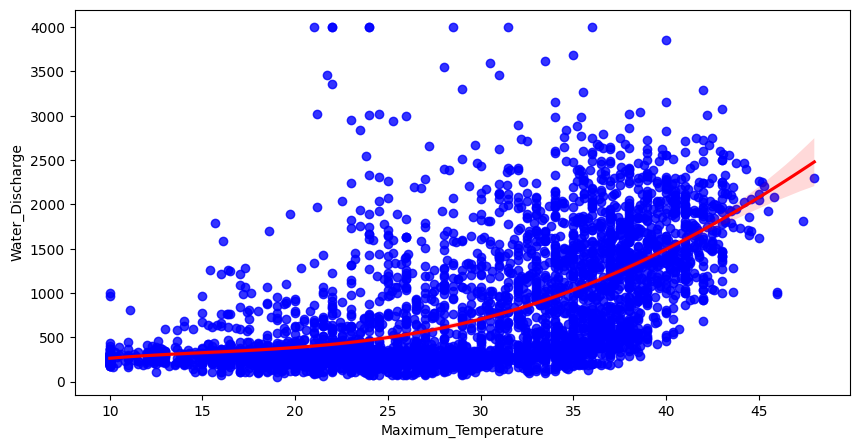

In [2]:
plt.figure(figsize=(10,5))
sns.regplot(
    x=df['Maximum_Temperature'],
    y=df['Water_Discharge'],
    order=4,
    scatter_kws={'color': 'blue'},
    line_kws={'color': 'red'}  # <-- change slope (line) color here
)

<Axes: xlabel='Rainfall', ylabel='Water_Discharge'>

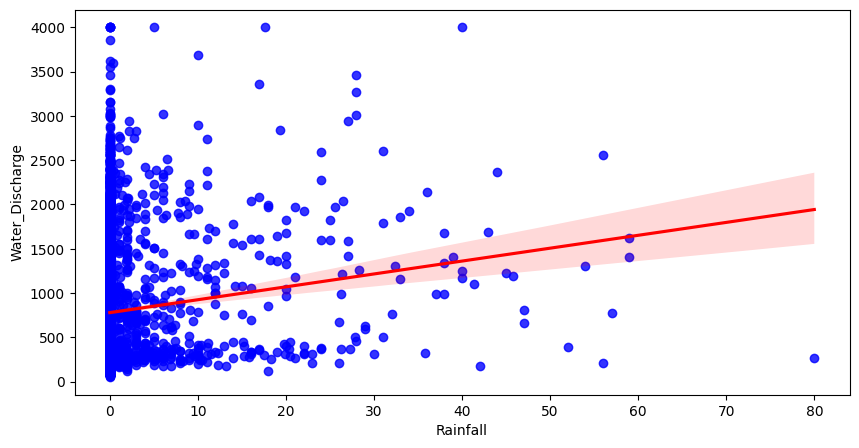

In [3]:
plt.figure(figsize=(10,5))
sns.regplot(
    x=df['Rainfall'],
    y=df['Water_Discharge'],
    scatter_kws={'color':'Blue'},
    line_kws={'color':'Red'}
)

In [4]:
df['Day']=df['Date'].dt.day
df['Month']=df['Date'].dt.month
df['Year']=df['Date'].dt.year

In [5]:
df=df.drop('Date',axis=1)

In [6]:
df.head()

,Maximum_Temperature,Minimum_Temperature,Average_Temperature,Rainfall,Water_Discharge,Temp_Diff,Day,Month,Year
0,22.0,5.0,11.35,0.00,185.5,17.0,1,1,2012
1,20.5,5.0,10.65,0.00,235.1,15.5,2,1,2012
2,20.8,5.0,10.90,0.00,235.0,15.8,3,1,2012
3,15.0,5.0,8.35,0.00,247.4,10.0,4,1,2012
4,15.0,5.4,10.20,0.05,267.9,9.6,5,1,2012


In [7]:
df=df[['Year','Month','Day','Maximum_Temperature','Minimum_Temperature','Rainfall','Average_Temperature','Water_Discharge','Temp_Diff']]

In [8]:
df.head()

,Year,Month,Day,Maximum_Temperature,Minimum_Temperature,Rainfall,Average_Temperature,Water_Discharge,Temp_Diff
0,2012,1,1,22.0,5.0,0.00,11.35,185.5,17.0
1,2012,1,2,20.5,5.0,0.00,10.65,235.1,15.5
2,2012,1,3,20.8,5.0,0.00,10.90,235.0,15.8
3,2012,1,4,15.0,5.0,0.00,8.35,247.4,10.0
4,2012,1,5,15.0,5.4,0.05,10.20,267.9,9.6


In [9]:
df=df.drop('Year',axis=1)

In [10]:
df.head()

,Month,Day,Maximum_Temperature,Minimum_Temperature,Rainfall,Average_Temperature,Water_Discharge,Temp_Diff
0,1,1,22.0,5.0,0.00,11.35,185.5,17.0
1,1,2,20.5,5.0,0.00,10.65,235.1,15.5
2,1,3,20.8,5.0,0.00,10.90,235.0,15.8
3,1,4,15.0,5.0,0.00,8.35,247.4,10.0
4,1,5,15.0,5.4,0.05,10.20,267.9,9.6


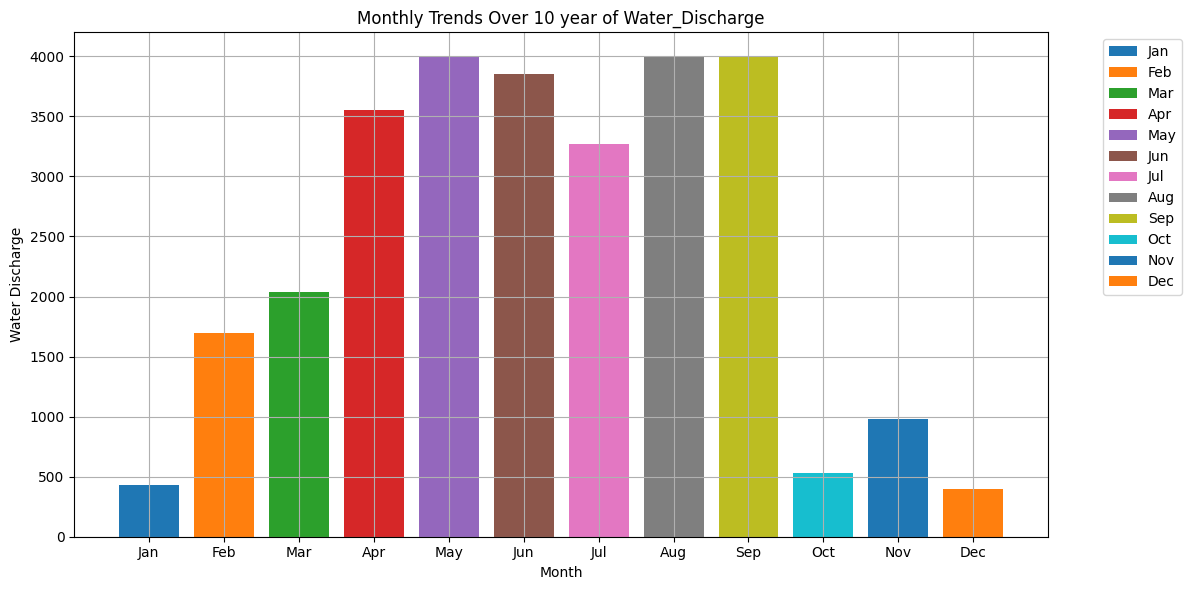

In [11]:
#
import calendar
plt.figure(figsize=(12, 6))

for month in df['Month'].unique():

    monthly_data = df[df['Month'] == month]
    plt.bar(monthly_data['Month'], monthly_data['Water_Discharge'], label=calendar.month_abbr[int(month)])
plt.xticks(ticks=range(1,13),labels=calendar.month_abbr[1:13])
plt.xlabel('Month')
plt.ylabel('Water Discharge')
plt.title('Monthly Trends Over 10 year of Water_Discharge')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()

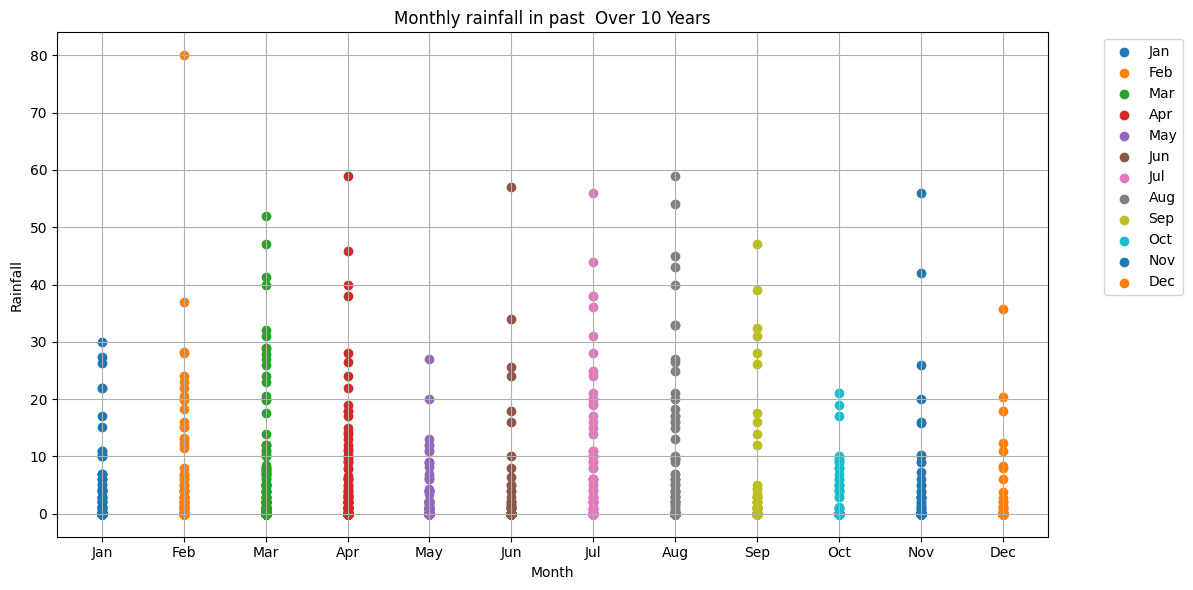

In [12]:
import matplotlib.pyplot as plt


plt.figure(figsize=(12, 6))

for month in df['Month'].unique():
    monthly_data = df[df['Month'] == month]
    plt.scatter(monthly_data['Month'], monthly_data['Rainfall'], label=calendar.month_abbr[int(month)])

# Set x-ticks to month names
plt.xticks(ticks=range(1, 13), labels=calendar.month_abbr[1:13])  # Jan to Dec

plt.xlabel('Month')
plt.ylabel('Rainfall')
plt.title('Monthly rainfall in past  Over 10 Years')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()

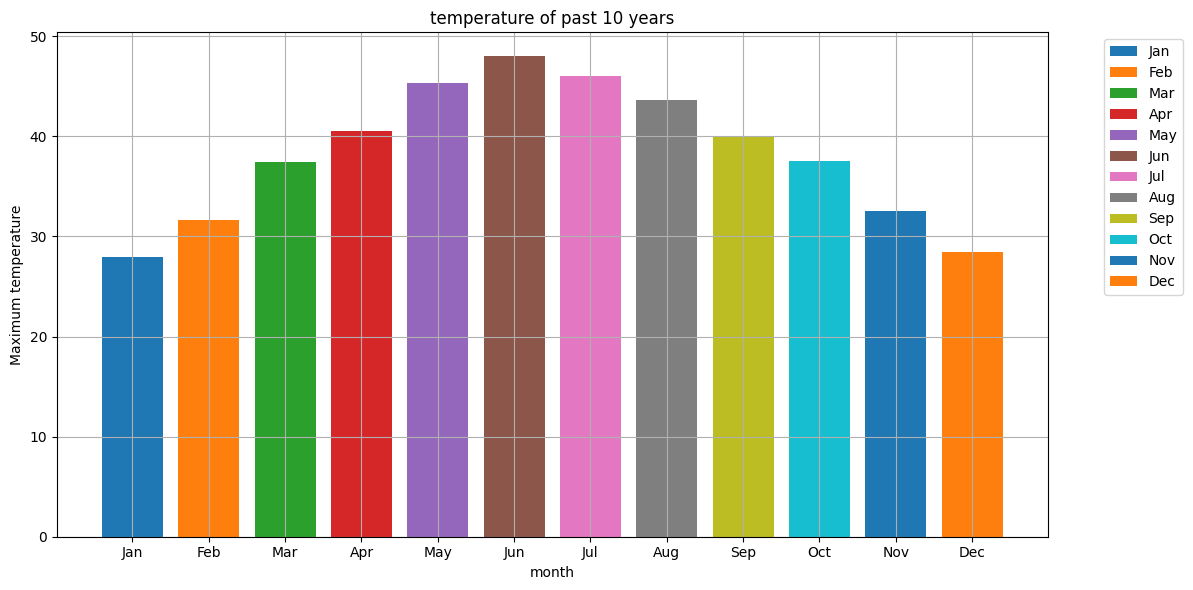

In [13]:
plt.figure(figsize=(12, 6))

for month in df['Month'].unique():

    monthly_data = df[df['Month'] == month]


    plt.bar(monthly_data['Month'], monthly_data['Maximum_Temperature'], label=calendar.month_abbr[int(month)])
plt.xticks(ticks=range(1,13),labels=calendar.month_abbr[1:13])
plt.xlabel('month')

plt.ylabel('Maximum temperature')
plt.title('temperature of past 10 years')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()

In [14]:
import numpy as np

df['Month_sin'] = np.sin(2 * np.pi * df['Month'] / 12)
df['Month_cos'] = np.cos(2 * np.pi * df['Month'] / 12)
df['Day_sin'] = np.sin(2 * np.pi * df['Day'] / 31)
df['Day_cos'] = np.cos(2 * np.pi * df['Day'] / 31)
df

,Month,Day,Maximum_Temperature,Minimum_Temperature,Rainfall,Average_Temperature,Water_Discharge,Temp_Diff,Month_sin,Month_cos,Day_sin,Day_cos
0,1,1,22.0,5.0,0.00,11.35,185.5,17.0,5.000000e-01,0.866025,2.012985e-01,0.979530
1,1,2,20.5,5.0,0.00,10.65,235.1,15.5,5.000000e-01,0.866025,3.943559e-01,0.918958
2,1,3,20.8,5.0,0.00,10.90,235.0,15.8,5.000000e-01,0.866025,5.712682e-01,0.820763
3,1,4,15.0,5.0,0.00,8.35,247.4,10.0,5.000000e-01,0.866025,7.247928e-01,0.688967
4,1,5,15.0,5.4,0.05,10.20,267.9,9.6,5.000000e-01,0.866025,8.486443e-01,0.528964
...,...,...,...,...,...,...,...,...,...,...,...,...
4013,12,27,10.0,5.0,0.00,7.00,211.2,5.0,-2.449294e-16,1.000000,-7.247928e-01,0.688967
4014,12,28,10.0,5.0,0.00,7.00,217.9,5.0,-2.449294e-16,1.000000,-5.712682e-01,0.820763
4015,12,29,10.0,5.0,0.00,7.00,227.7,5.0,-2.449294e-16,1.000000,-3.943559e-01,0.918958
4016,12,30,10.0,5.0,8.00,7.00,234.2,5.0,-2.449294e-16,1.000000,-2.012985e-01,0.979530


In [15]:
df=df.drop(['Month','Day'],axis=1)#no need of these column

x=df[['Maximum_Temperature','Minimum_Temperature','Average_Temperature','Rainfall','Month_sin','Month_cos','Day_sin','Day_cos','Temp_Diff']]
y=df['Water_Discharge']

In [16]:
df.head()

,Maximum_Temperature,Minimum_Temperature,Rainfall,Average_Temperature,Water_Discharge,Temp_Diff,Month_sin,Month_cos,Day_sin,Day_cos
0,22.0,5.0,0.00,11.35,185.5,17.0,0.5,0.866025,0.201299,0.979530
1,20.5,5.0,0.00,10.65,235.1,15.5,0.5,0.866025,0.394356,0.918958
2,20.8,5.0,0.00,10.90,235.0,15.8,0.5,0.866025,0.571268,0.820763
3,15.0,5.0,0.00,8.35,247.4,10.0,0.5,0.866025,0.724793,0.688967
4,15.0,5.4,0.05,10.20,267.9,9.6,0.5,0.866025,0.848644,0.528964


In [17]:
print(df['Rainfall'].max())

80.0


In [18]:
x=df.drop(columns=['Water_Discharge'])
y=df['Water_Discharge']

Feature matrix shape : (3997, 49)
Total features       : 49  (9 base + 40 lag)
Train size: 3197 | Test size: 800
Test period:
3217
3996

--- LSTM (Fixed: sequence on base features, lags as current-step context) ---
Sequence input shape : (3177, 20, 9)
Aux input shape      : (3177, 49)
  Fold 1 R²: 0.9121
  Fold 2 R²: 0.9677
  Fold 3 R²: 0.9379
  Fold 4 R²: 0.9621
  Fold 5 R²: 0.9272
Average CV R²: 0.9414 ± 0.0209
Epoch 1/200
90/90 ━━━━━━━━━━━━━━━━━━━━ 10s 40ms/step - loss: 0.0063 - val_loss: 0.0064
Epoch 2/200
90/90 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - loss: 0.0036 - val_loss: 0.0065
Epoch 3/200
90/90 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - loss: 0.0030 - val_loss: 0.0050
Epoch 4/200
90/90 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - loss: 0.0025 - val_loss: 0.0048
Epoch 5/200
90/90 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - loss: 0.0022 - val_loss: 0.0045
Epoch 6/200
90/90 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - loss: 0.0021 - val_loss: 0.0044
Epoch 7/200
90/90 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - loss: 0.0020

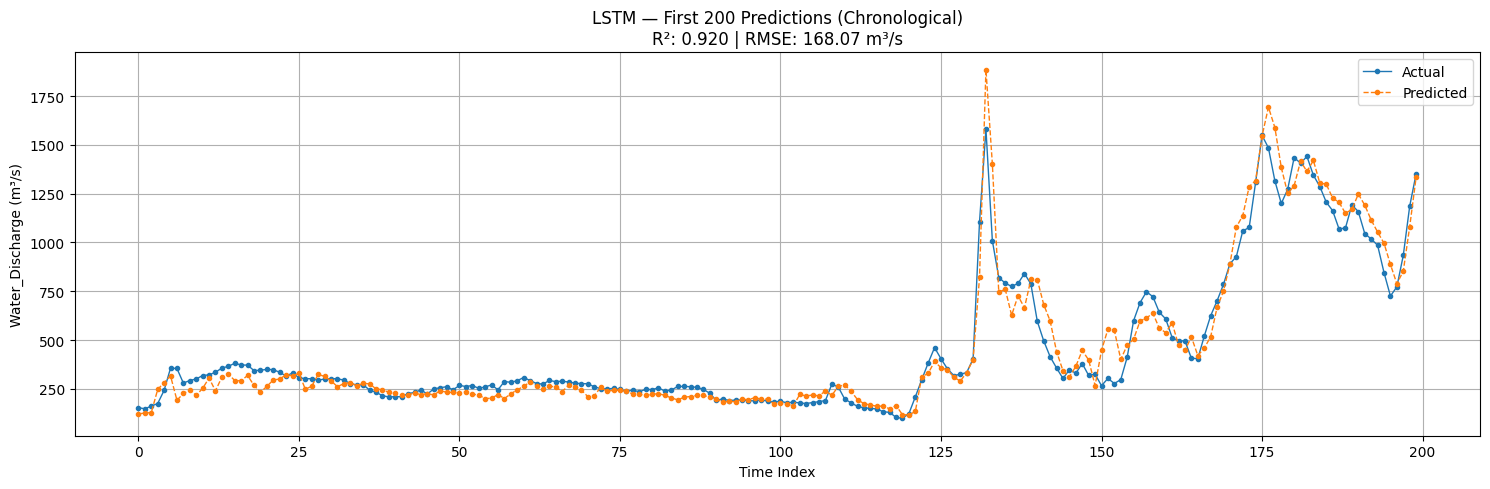

Graph saved: graph_lstm_with_gridsearch_cv.png


In [19]:
# All Six Models: Random Forest, XGBoost, SVM, Ridge Regression, ANN, LSTM
# K-Fold Temporal CV + GridSearchCV + Lag Features for fair comparison

# ===================== IMPORTS =====================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle

from sklearn.preprocessing import MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import KFold, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.svm import SVR
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import xgboost as xgb

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, LSTM
from tensorflow.keras.callbacks import EarlyStopping


# ===================== STEP 1: FEATURE ENGINEERING =====================
# Add lag features (20 days) — gives ML models same historical context as ANN/LSTM
for lag in range(1, 21):
    df[f'Discharge_lag_{lag}'] = df['Water_Discharge'].shift(lag)
    df[f'Rainfall_lag_{lag}']  = df['Rainfall'].shift(lag)

# Drop first 20 rows where lag values are NaN
df = df.dropna().reset_index(drop=True)


# ===================== STEP 2: FEATURE MATRIX =====================
lag_cols  = [f'Discharge_lag_{i}' for i in range(1, 21)] + \
            [f'Rainfall_lag_{i}'  for i in range(1, 21)]

base_cols = ['Maximum_Temperature', 'Minimum_Temperature', 'Average_Temperature',
             'Rainfall', 'Month_sin', 'Month_cos', 'Day_sin', 'Day_cos', 'Temp_Diff']

x = df[base_cols + lag_cols]
y = df['Water_Discharge']

print(f"Feature matrix shape : {x.shape}")
print(f"Total features       : {x.shape[1]}  (9 base + 40 lag)")


# ===================== STEP 3: CHRONOLOGICAL SPLIT =====================
split_index = int(len(x) * 0.8)

X_train = x.iloc[:split_index]
X_test  = x.iloc[split_index:]
y_train = y.iloc[:split_index]
y_test  = y.iloc[split_index:]

print(f"Train size: {len(X_train)} | Test size: {len(X_test)}")

print("Test period:")
print(df.index[split_index + 20])
print(df.index[-1])

# ===================== STEP 4: NORMALIZATION =====================
# Used for RF and XGBoost directly
# SVM and Ridge handle scaling internally via Pipeline
# ANN and LSTM use their own scaler defined inside their functions
scaler = MinMaxScaler()
X_train_norm = scaler.fit_transform(X_train)
X_test_norm  = scaler.transform(X_test)


# ===================== STEP 5: K-FOLD (NO SHUFFLE) =====================
kf = KFold(n_splits=5, shuffle=False)


# ===================== STEP 6: METRICS FUNCTION =====================
def print_metrics(y_true, y_pred, model_name="Model"):
    r2   = r2_score(y_true, y_pred)
    mse  = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae  = mean_absolute_error(y_true, y_pred)

    print(f"\n{'='*45}")
    print(f"  {model_name} — Test Metrics")
    print(f"{'='*45}")
    print(f"  R²   : {r2:.4f}")
    print(f"  MSE  : {mse:.4f}")
    print(f"  RMSE : {rmse:.4f} m³/s")
    print(f"  MAE  : {mae:.4f} m³/s")
    print(f"{'='*45}")

    return r2, mse, rmse, mae


# ===================== STEP 7: PLOT & SAVE FUNCTION =====================
def plot_results(y_true, y_pred, model_name, n=200):
    y_true_arr = np.array(y_true).flatten()
    y_pred_arr = np.array(y_pred).flatten()
    n = min(n, len(y_true_arr))

    y_true_subset = y_true_arr[:n]
    y_pred_subset = y_pred_arr[:n]

    # --- Save Excel ---
    results_table = pd.DataFrame({
        "Index"               : range(n),
        "Actual_Discharge"    : y_true_subset,
        "Predicted_Discharge" : y_pred_subset,
        "Error"               : y_true_subset - y_pred_subset
    })

    filename_excel = f"{model_name.lower().replace(' ', '_')}_with_gridsearch_cv_predictions.xlsx"
    results_table.to_excel(filename_excel, index=False)
    print(f"Table saved: {filename_excel}")

    # --- Save Plot ---
    plt.figure(figsize=(15, 5))
    plt.plot(y_true_subset, label="Actual",    marker="o", markersize=3, linewidth=1)
    plt.plot(y_pred_subset, label="Predicted", marker="o", markersize=3,
             linewidth=1, linestyle="--")
    plt.title(f"{model_name} — First {n} Predictions (Chronological)\n"
              f"R²: {r2_score(y_true_arr, y_pred_arr):.3f} | "
              f"RMSE: {np.sqrt(mean_squared_error(y_true_arr, y_pred_arr)):.2f} m³/s")
    plt.xlabel("Time Index")
    plt.ylabel("Water_Discharge (m³/s)")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()

    filename_graph = f"graph_{model_name.lower().replace(' ', '_')}_with_gridsearch_cv.png"
    plt.savefig(filename_graph, dpi=300, bbox_inches="tight")
    plt.show()
    print(f"Graph saved: {filename_graph}")


# ===================== STEP 8: LSTM HELPER — SEQUENCE BUILDER =====================
# Builds sliding window sequences for LSTM from base features only
# Each sample = 20 consecutive days of 9 base features → LSTM learns temporal pattern
# window=20 matches the lag window used by all other models for fair comparison

def make_sequences(X_scaled, y_arr, window=20):
    Xs, ys = [], []
    for i in range(window, len(X_scaled)):
        Xs.append(X_scaled[i - window:i])   # shape: (window, n_features)
        ys.append(y_arr[i])                  # target: next day discharge
    return np.array(Xs), np.array(ys)


# ===================== STEP 9: MODEL RUNNERS =====================

# ---- Random Forest: scale-invariant, no Pipeline needed ----
def run_random_forest():
    print("\n--- Random Forest (GridSearch + 5-Fold Temporal CV) ---")

    param_grid = {
        "n_estimators"     : [100, 160],
        "max_depth"        : [None, 10, 20],
        "min_samples_split": [2, 5]
    }

    grid = GridSearchCV(
        RandomForestRegressor(random_state=42),
        param_grid,
        cv=kf,
        scoring="r2",
        n_jobs=-1
    )

    grid.fit(X_train_norm, y_train)

    print(f"Best Params : {grid.best_params_}")
    print(f"Best CV R²  : {grid.best_score_:.4f}")

    predictions = grid.best_estimator_.predict(X_test_norm)
    print_metrics(y_test, predictions, "Random Forest")
    plot_results(y_test, predictions, "Random Forest")


# ---- XGBoost: scale-invariant, no Pipeline needed ----
def run_xgboost():
    print("\n--- XGBoost (GridSearch + 5-Fold Temporal CV) ---")

    param_grid = {
        "n_estimators" : [100, 160],
        "learning_rate": [0.05, 0.1],
        "max_depth"    : [3, 5, 7],
        "subsample"    : [0.8, 1.0]
    }

    grid = GridSearchCV(
        xgb.XGBRegressor(objective="reg:squarederror", random_state=42),
        param_grid,
        cv=kf,
        scoring="r2",
        n_jobs=-1
    )

    grid.fit(X_train_norm, y_train)

    print(f"Best Params : {grid.best_params_}")
    print(f"Best CV R²  : {grid.best_score_:.4f}")

    predictions = grid.best_estimator_.predict(X_test_norm)
    print_metrics(y_test, predictions, "XGBoost")
    plot_results(y_test, predictions, "XGBoost")


# ---- SVM: scale-sensitive, Pipeline wraps GridSearchCV (NO leakage) ----
def run_svm():
    print("\n--- SVM (GridSearch + 5-Fold Temporal CV + Pipeline) ---")

    param_grid = {
        "svm__C"      : [1, 10, 100],
        "svm__gamma"  : ["scale", 0.1, 0.01],
        "svm__epsilon": [0.1, 0.2]
    }

    pipeline = Pipeline([
        ("scaler", MinMaxScaler()),
        ("svm",    SVR(kernel="rbf"))
    ])

    grid = GridSearchCV(
        pipeline,
        param_grid,
        cv=kf,
        scoring="r2",
        n_jobs=-1
    )

    # Pass RAW X_train — Pipeline fits scaler on train fold only, each iteration
    grid.fit(X_train, y_train)

    print(f"Best Params : {grid.best_params_}")
    print(f"Best CV R²  : {grid.best_score_:.4f}")

    # Pipeline scales X_test internally during predict
    predictions = grid.best_estimator_.predict(X_test)
    print_metrics(y_test, predictions, "SVM")
    plot_results(y_test, predictions, "SVM")


# ---- Ridge: scale-sensitive, Pipeline wraps GridSearchCV (NO leakage) ----
def run_ridge():
    print("\n--- Ridge Regression (GridSearch + 5-Fold Temporal CV + Pipeline) ---")

    param_grid = {
        "ridge__alpha": [0.01, 0.1, 1, 10, 100]
    }

    pipeline = Pipeline([
        ("scaler", MinMaxScaler()),
        ("ridge",  Ridge())
    ])

    grid = GridSearchCV(
        pipeline,
        param_grid,
        cv=kf,
        scoring="r2",
        n_jobs=-1
    )

    # Pass RAW X_train — Pipeline fits scaler per fold internally
    grid.fit(X_train, y_train)

    best_pipeline = grid.best_estimator_

    print(f"Best Params : {grid.best_params_}")
    print(f"Best CV R²  : {grid.best_score_:.4f}")

    predictions = best_pipeline.predict(X_test)
    print_metrics(y_test, predictions, "Ridge Regression")
    plot_results(y_test, predictions, "Ridge Regression")

    # Save pipeline (includes scaler + model — no separate scaler needed)
    with open("ridge_pipeline_with_gridsearch_cv.pkl", "wb") as f:
        pickle.dump(best_pipeline, f)
    print("Ridge pipeline saved as ridge_pipeline_with_gridsearch_cv.pkl")


# ---- ANN: scale-sensitive, own scaler, no GridSearch (Keras not compatible) ----
def run_ann():
    print("\n--- ANN (5-Fold Temporal CV — EarlyStopping) ---")

    # ANN uses its own scaler fitted on X_train only
    ann_scaler = MinMaxScaler()
    X_train_ann = ann_scaler.fit_transform(X_train)
    X_test_ann  = ann_scaler.transform(X_test)

    y_train_arr = np.array(y_train)
    y_test_arr  = np.array(y_test)

    # K-Fold CV to report training stability
    cv_r2_scores = []
    for fold, (train_idx, val_idx) in enumerate(kf.split(X_train_ann)):
        X_fold_train, X_fold_val = X_train_ann[train_idx], X_train_ann[val_idx]
        y_fold_train, y_fold_val = y_train_arr[train_idx], y_train_arr[val_idx]

        model = Sequential([
            Dense(128, activation='relu', input_shape=(X_train_ann.shape[1],)),
            BatchNormalization(),
            Dropout(0.3),
            Dense(64, activation='relu'),
            Dropout(0.2),
            Dense(32, activation='relu'),
            Dense(1)
        ])
        model.compile(optimizer='adam', loss='mse')

        es = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
        model.fit(X_fold_train, y_fold_train,
                  validation_data=(X_fold_val, y_fold_val),
                  epochs=100, batch_size=32,
                  callbacks=[es], verbose=0)

        val_pred  = model.predict(X_fold_val, verbose=0).flatten()
        fold_r2   = r2_score(y_fold_val, val_pred)
        cv_r2_scores.append(fold_r2)
        print(f"  Fold {fold+1} R²: {fold_r2:.4f}")

    print(f"Average CV R²: {np.mean(cv_r2_scores):.4f} ± {np.std(cv_r2_scores):.4f}")

    # Final model trained on full training data
    final_model = Sequential([
        Dense(128, activation='relu', input_shape=(X_train_ann.shape[1],)),
        BatchNormalization(),
        Dropout(0.3),
        Dense(64, activation='relu'),
        Dropout(0.2),
        Dense(32, activation='relu'),
        Dense(1)
    ])
    final_model.compile(optimizer='adam', loss='mse')

    es = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
    final_model.fit(X_train_ann, y_train_arr,
                    validation_split=0.1,
                    epochs=200, batch_size=32,
                    callbacks=[es], verbose=1)

    predictions = final_model.predict(X_test_ann, verbose=0).flatten()
    print_metrics(y_test_arr, predictions, "ANN")
    plot_results(y_test_arr, predictions, "ANN")

def run_lstm():
    print("\n--- LSTM (Fixed: sequence on base features, lags as current-step context) ---")

    WINDOW = 20

    base_cols = [
        'Maximum_Temperature', 'Minimum_Temperature', 'Average_Temperature',
        'Rainfall', 'Month_sin', 'Month_cos', 'Day_sin', 'Day_cos', 'Temp_Diff'
    ]
    lag_cols = [f'Discharge_lag_{i}' for i in range(1, 21)] + \
               [f'Rainfall_lag_{i}'  for i in range(1, 21)]

    # Sequence input: only base features over 20 timesteps — LSTM learns temporal pattern
    X_seq_part  = X_train[base_cols].values   # (n_train, 9)
    X_seq_test_part = X_test[base_cols].values

    # Auxiliary input: all 49 features at current timestep only — gives LSTM the lag context
    X_aux_part  = X_train[base_cols + lag_cols].values   # (n_train, 49)
    X_aux_test_part = X_test[base_cols + lag_cols].values

    y_train_arr = np.array(y_train).reshape(-1, 1)
    y_test_arr  = np.array(y_test).flatten()

    # Scale both inputs — fit on train only
    seq_scaler = MinMaxScaler()
    aux_scaler = MinMaxScaler()
    lstm_y_scaler = MinMaxScaler()

    X_seq_scaled      = seq_scaler.fit_transform(X_seq_part)
    X_seq_test_scaled = seq_scaler.transform(X_seq_test_part)

    X_aux_scaled      = aux_scaler.fit_transform(X_aux_part)
    X_aux_test_scaled = aux_scaler.transform(X_aux_test_part)

    y_train_scaled = lstm_y_scaler.fit_transform(y_train_arr).flatten()

    # Build sequences for the base-feature window
    X_seq_train_3d, y_seq_train = make_sequences(X_seq_scaled,      y_train_scaled, window=WINDOW)
    X_seq_test_3d,  y_seq_test  = make_sequences(X_seq_test_scaled,  y_test_arr,     window=WINDOW)

    # Aux input: take the row at position i (current timestep) for each sequence
    # make_sequences uses range(window, len(X)), so aux aligns at those same indices
    X_aux_train_2d = X_aux_scaled[WINDOW:]        # shape: (n_train-20, 49)
    X_aux_test_2d  = X_aux_test_scaled[WINDOW:]   # shape: (n_test-20,  49)

    print(f"Sequence input shape : {X_seq_train_3d.shape}")  # (n-20, 20, 9)
    print(f"Aux input shape      : {X_aux_train_2d.shape}")  # (n-20, 49)

    from tensorflow.keras.layers import Input, Concatenate, Flatten
    from tensorflow.keras.models import Model

    def build_model():
        # Branch 1: LSTM on 20-step window of 9 base features
        seq_input = Input(shape=(WINDOW, 9), name='seq_input')
        x = LSTM(64, return_sequences=True)(seq_input)
        x = Dropout(0.2)(x)
        x = LSTM(32, return_sequences=False)(x)
        x = Dropout(0.2)(x)

        # Branch 2: direct dense on 49 current-step features (incl. lags)
        aux_input = Input(shape=(49,), name='aux_input')
        a = Dense(32, activation='relu')(aux_input)

        # Merge both branches
        merged = Concatenate()([x, a])
        merged = Dense(32, activation='relu')(merged)
        output = Dense(1)(merged)

        model = Model(inputs=[seq_input, aux_input], outputs=output)
        model.compile(optimizer='adam', loss='mse')
        return model

    # K-Fold CV
    cv_r2_scores = []
    for fold, (train_idx, val_idx) in enumerate(kf.split(X_seq_train_3d)):
        model = build_model()
        es = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
        model.fit(
            [X_seq_train_3d[train_idx], X_aux_train_2d[train_idx]],
            y_seq_train[train_idx],
            validation_data=(
                [X_seq_train_3d[val_idx], X_aux_train_2d[val_idx]],
                y_seq_train[val_idx]
            ),
            epochs=100, batch_size=32, callbacks=[es], verbose=0
        )
        val_pred = lstm_y_scaler.inverse_transform(
            model.predict([X_seq_train_3d[val_idx], X_aux_train_2d[val_idx]], verbose=0).reshape(-1,1)
        ).flatten()
        val_true = lstm_y_scaler.inverse_transform(
            y_seq_train[val_idx].reshape(-1,1)
        ).flatten()
        fold_r2 = r2_score(val_true, val_pred)
        cv_r2_scores.append(fold_r2)
        print(f"  Fold {fold+1} R²: {fold_r2:.4f}")

    print(f"Average CV R²: {np.mean(cv_r2_scores):.4f} ± {np.std(cv_r2_scores):.4f}")

    # Final model
    final_model = build_model()
    es = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
    final_model.fit(
        [X_seq_train_3d, X_aux_train_2d], y_seq_train,
        validation_split=0.1,
        epochs=200, batch_size=32, callbacks=[es], verbose=1
    )

    pred_scaled = final_model.predict(
        [X_seq_test_3d, X_aux_test_2d], verbose=0
    ).flatten()
    predictions = lstm_y_scaler.inverse_transform(
        pred_scaled.reshape(-1,1)
    ).flatten()

    print_metrics(y_seq_test, predictions, "LSTM")
    plot_results(y_seq_test, predictions, "LSTM")
# ===================== STEP 10: RUN ALL =====================
run_random_forest()
run_xgboost()
run_svm()
run_ridge()
run_ann()
run_lstm()